# Round 5 — Data Analysis

50 new products in 10 categories of 5. Three days of data (`day 2`, `day 3`,
`day 4`). Position limit is 10 per product.

Goal of this notebook is to **inspect every product** and **find the categories
where price movement carries exploitable structure**. The wiki hints that some
categories embed strong patterns; the rest will need plain market-making.

The flow:

  1. Load + inventory
  2. Per-product price stats
  3. **Per-category PCA** — find linear combinations with vanishing variance
  4. **PEBBLES deep dive** — the one near-deterministic basket
  5. **SNACKPACK deep dive** — a cointegrated pair plus a softer 3-asset block
  6. Sweep of the other eight categories
  7. Microstructure (spread, depth)
  8. Per-product mean reversion (do we want single-name reversion?)
  9. Day-to-day non-stationarity (level drift)
  10. Strategy implications

## 0 — Setup & data inventory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

DATA = Path('../Data')
DAYS = [2, 3, 4]

prices = pd.concat([
    pd.read_csv(DATA / f'prices_round_5_day_{d}.csv', sep=';').assign(day=d)
    for d in DAYS
], ignore_index=True)
trades = pd.concat([
    pd.read_csv(DATA / f'trades_round_5_day_{d}.csv', sep=';').assign(day=d)
    for d in DAYS
], ignore_index=True)

print(f'prices rows: {len(prices):,}, trades rows: {len(trades):,}')
print(f'days: {sorted(prices.day.unique())}, ticks/day: {prices.timestamp.nunique()}')
print(f'products: {prices["product"].nunique()}')
prices.head(3)

prices rows: 1,500,000, trades rows: 35,385
days: [np.int64(2), np.int64(3), np.int64(4)], ticks/day: 10000
products: 50


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,PEBBLES_L,9994,13,9992.0,21.0,NaN,NaN,10006,13,10008.0,21.0,NaN,NaN,10000.0,0.0
1,2,0,SNACKPACK_RASPBERRY,9992,36,9990.0,45.0,NaN,NaN,10008,36,10010.0,45.0,NaN,NaN,10000.0,0.0
2,2,0,UV_VISOR_RED,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0


**Note** — the `trades` files have empty `buyer` / `seller` columns this round,
so the counterparty signal we used in earlier rounds is gone.

## 1 — The 10 categories

In [2]:
CATEGORIES = {
    'GALAXY_SOUNDS':  ['DARK_MATTER', 'BLACK_HOLES', 'PLANETARY_RINGS', 'SOLAR_WINDS', 'SOLAR_FLAMES'],
    'SLEEP_POD':      ['SUEDE', 'LAMB_WOOL', 'POLYESTER', 'NYLON', 'COTTON'],
    'MICROCHIP':      ['CIRCLE', 'OVAL', 'SQUARE', 'RECTANGLE', 'TRIANGLE'],
    'PEBBLES':        ['XS', 'S', 'M', 'L', 'XL'],
    'ROBOT':          ['VACUUMING', 'MOPPING', 'DISHES', 'LAUNDRY', 'IRONING'],
    'UV_VISOR':       ['YELLOW', 'AMBER', 'ORANGE', 'RED', 'MAGENTA'],
    'TRANSLATOR':     ['SPACE_GRAY', 'ASTRO_BLACK', 'ECLIPSE_CHARCOAL', 'GRAPHITE_MIST', 'VOID_BLUE'],
    'PANEL':          ['1X2', '2X2', '1X4', '2X4', '4X4'],
    'OXYGEN_SHAKE':   ['MORNING_BREATH', 'EVENING_BREATH', 'MINT', 'CHOCOLATE', 'GARLIC'],
    'SNACKPACK':      ['CHOCOLATE', 'VANILLA', 'PISTACHIO', 'STRAWBERRY', 'RASPBERRY'],
}
def full(cat, suf): return f'{cat}_{suf}'
def cols_of(cat):   return [full(cat, s) for s in CATEGORIES[cat]]

# Wide pivot: rows = (day, ts), cols = product, values = mid
pv = (prices
      .pivot_table(index=['day', 'timestamp'], columns='product', values='mid_price')
      .sort_index())
print(f'pivot shape: {pv.shape}  ({pv.shape[0]:,} snapshots × {pv.shape[1]} products)')

pivot shape: (30000, 50)  (30,000 snapshots × 50 products)


## 2 — Per-product price stats

**Purpose.** Before we look for cross-product structure (PCA, basket arbs),
we want a one-line description of each of the 50 products: where its price
lives, how much it moves around, and whether it's a "small ticker" or a "big
ticker". This tells us which products will dominate risk if we trade them
naively, and gives us the denominators we'll need later when comparing
microstructure quantities (e.g. a 1-tick spread means very different things
on a 200-priced product vs. a 15,000-priced one).

**Statistics computed (over all 3 days, per product):**

* `mean` — average mid price. Roughly "where the product trades".
* `std` — standard deviation of the mid price, in absolute price units (ticks).
  A std of 1,800 means the price typically wanders ±1,800 ticks around its
  mean.
* `min` / `max` — extremes observed across the 3 days.
* `range` = `max − min`. The full peak-to-trough swing.
* `cv_%` — **coefficient of variation**, defined as `std / mean × 100`.

**What is `cv_%` and why include it?** Raw `std` is in price units, so it
isn't comparable across products that trade at different price levels — a std
of 100 is enormous for a product priced at 200, but tiny for one priced at
15,000. Dividing by the mean rescales volatility into a *percentage of price*,
putting all 50 products on the same footing.

* `cv_%` ≈ 1 → price typically moves about 1% around its level (calm).
* `cv_%` ≈ 20 → price routinely swings ±20% of its average (frenetic).

So `cv_%` is the right metric for ranking which products are *intrinsically*
volatile, regardless of where they happen to trade.

*Caveat.* `cv_%` here is computed on raw mid prices over 3 days, not on
returns. For products that drift heavily day-to-day, the "mean" is a moving
target, so a high `cv_%` can reflect either tick-by-tick volatility *or*
level drift across days. We separate those two effects in section 9.

In [3]:
stats = pv.agg(['mean', 'std', 'min', 'max']).T
stats['range'] = stats['max'] - stats['min']
stats['cv_%']  = (stats['std'] / stats['mean'] * 100).round(2)
stats = stats.round(1).sort_index()

# Tag with category
stats['category'] = [c.split('_')[0] if not c.startswith(('GALAXY','SLEEP','OXYGEN','UV')) else
                     ('GALAXY_SOUNDS' if c.startswith('GALAXY') else
                      'SLEEP_POD'     if c.startswith('SLEEP') else
                      'OXYGEN_SHAKE'  if c.startswith('OXYGEN') else
                      'UV_VISOR') for c in stats.index]
stats[['category','mean','std','range','cv_%']]

,category,mean,std,range,cv_%
product,,,,,
GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS,11466.9,958.4,4528.5,8.4
GALAXY_SOUNDS_DARK_MATTER,GALAXY_SOUNDS,10226.7,330.7,1645.0,3.2
GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS,10766.7,765.8,2929.0,7.1
GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS,11092.6,450.2,2372.5,4.1
GALAXY_SOUNDS_SOLAR_WINDS,GALAXY_SOUNDS,10437.5,541.1,2293.5,5.2
MICROCHIP_CIRCLE,MICROCHIP,9214.9,532.5,2428.0,5.8
MICROCHIP_OVAL,MICROCHIP,8179.6,1551.9,5058.0,19.0
MICROCHIP_RECTANGLE,MICROCHIP,8732.4,752.0,3115.0,8.6
MICROCHIP_SQUARE,MICROCHIP,13594.7,1830.3,6742.0,13.5


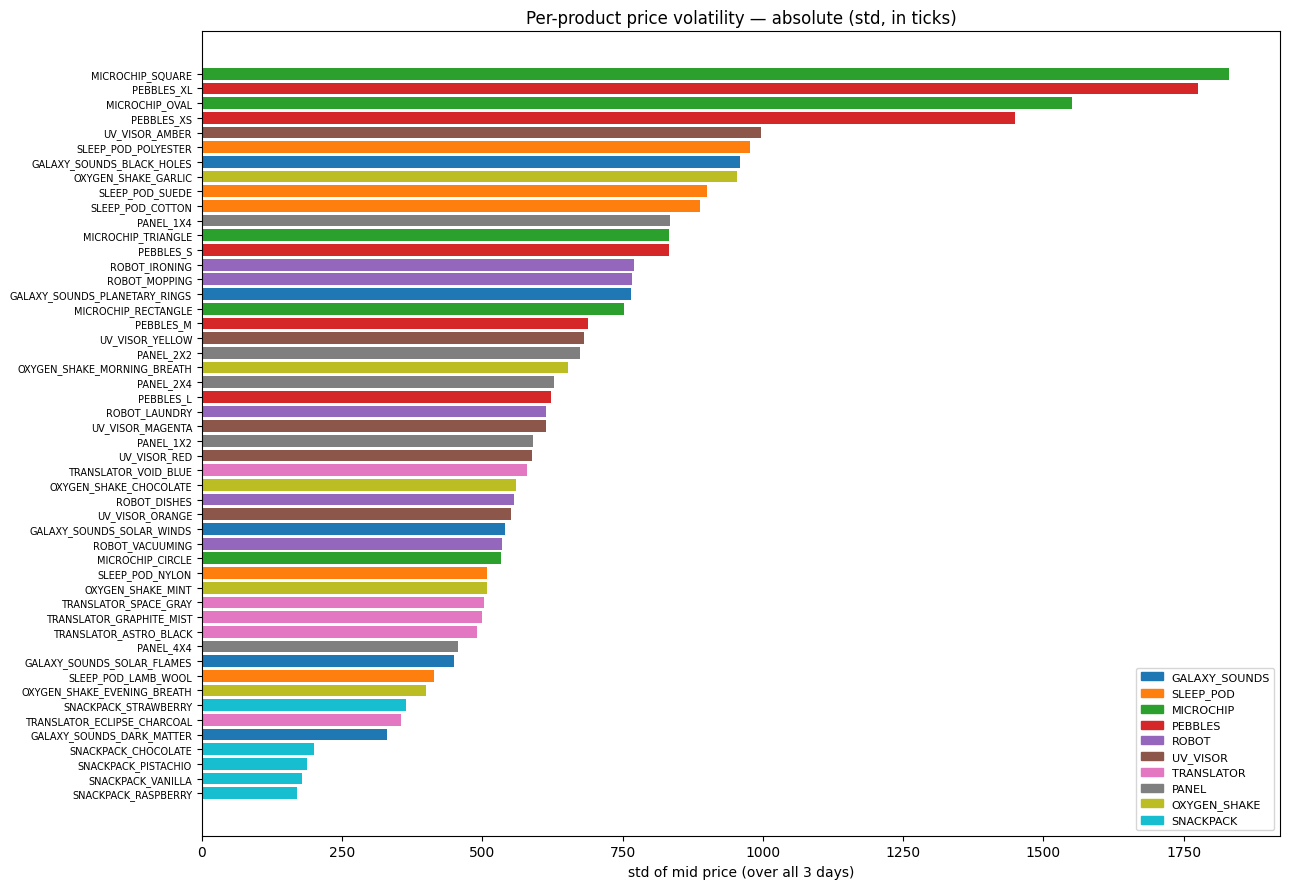

In [4]:
# Std bar chart per product, coloured by category
order = stats.sort_values('std', ascending=False).index.tolist()
cat_order = list(CATEGORIES.keys())
cmap = {c: plt.cm.tab10(i) for i, c in enumerate(cat_order)}

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(range(len(order)), stats.loc[order, 'std'],
        color=[cmap[stats.loc[p, 'category']] for p in order])
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('std of mid price (over all 3 days)')
ax.set_title('Per-product price volatility — absolute (std, in ticks)')
ax.legend(handles=[plt.Rectangle((0,0),1,1, color=cmap[c], label=c) for c in cat_order],
          loc='lower right', fontsize=8)
plt.tight_layout()

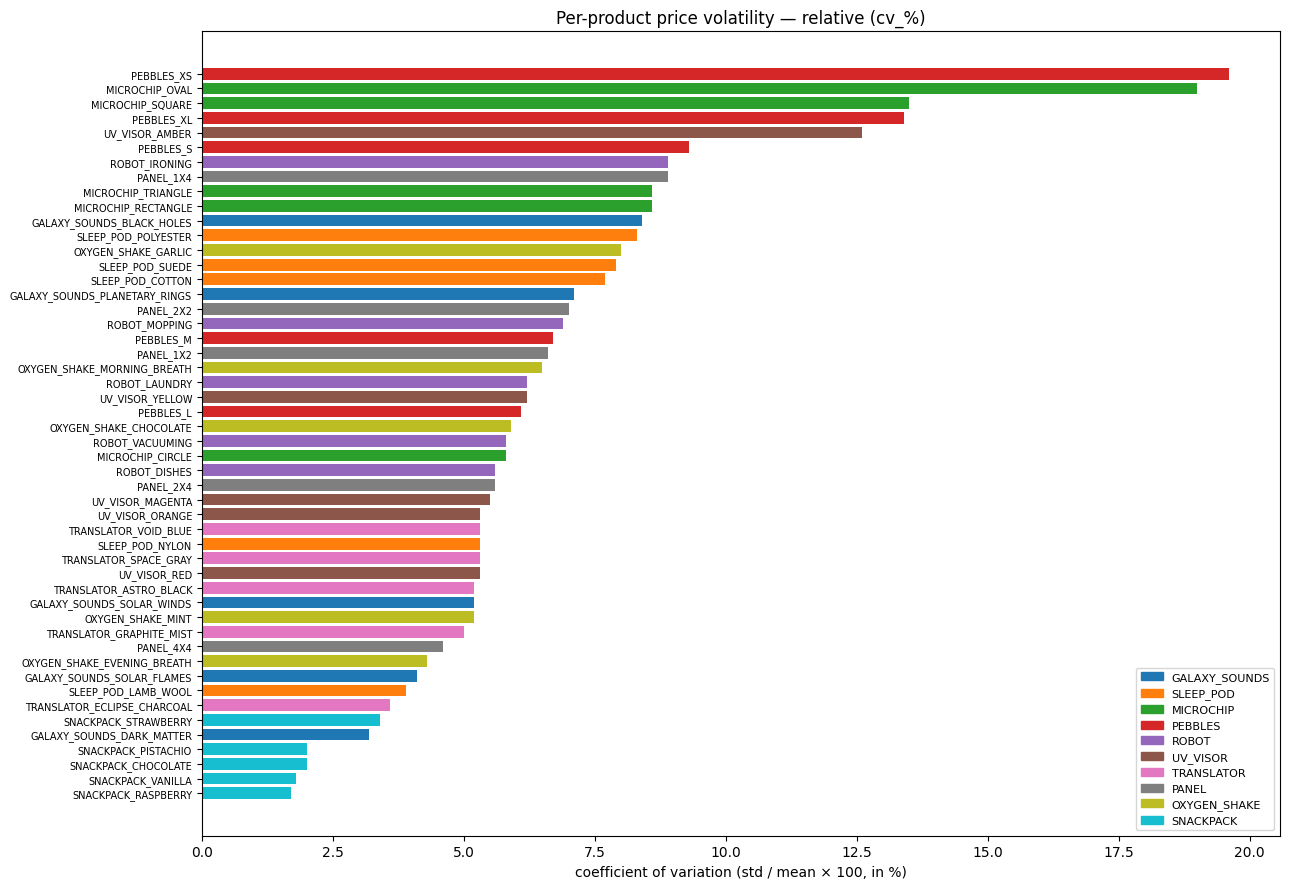

In [5]:
# Same bar chart but sorted/sized by cv_% (relative volatility)
order_cv = stats.sort_values('cv_%', ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(range(len(order_cv)), stats.loc[order_cv, 'cv_%'],
        color=[cmap[stats.loc[p, 'category']] for p in order_cv])
ax.set_yticks(range(len(order_cv)))
ax.set_yticklabels(order_cv, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('coefficient of variation (std / mean × 100, in %)')
ax.set_title('Per-product price volatility — relative (cv_%)')
ax.legend(handles=[plt.Rectangle((0,0),1,1, color=cmap[c], label=c) for c in cat_order],
          loc='lower right', fontsize=8)
plt.tight_layout()

**Read.** The two charts answer different questions.

* **Absolute (std).** Tells us *how many ticks of P&L variance* a single lot
  of each product would generate. The biggest movers — `MICROCHIP_SQUARE`,
  `PEBBLES_XL` — have std ~1,800 and wander 6,000+ across the three days. The
  `SNACKPACK` family is the calmest in absolute terms, std under 200.
* **Relative (cv_%).** Strips out the price level and tells us *how violently
  the product moves as a fraction of where it trades*. Products that trade
  cheap but still swing a lot rise to the top, while expensive but slow-moving
  products fall.

The ranking shuffles meaningfully between the two views: a product can be a
"big mover" in std terms simply because it's expensive, while another with
small std but a low price level can be far more volatile in percentage terms.
For market making, `cv_%` is what governs whether a fixed-tick spread is
generous or razor-thin; for sizing absolute risk, raw `std` is what matters.

Within a category the five members can also have very different vols on
either axis (e.g. PEBBLES: XL std=1776 vs L std=622) — useful to keep in mind
when we look at basket structure in the next section.

## 3 — Per-category PCA: where is the structure hiding?

**Goal.** Within each 5-product category, we want to know: is there a fixed
*recipe* of the five prices — something like `XS + S + M + L + XL` or
`CHOC + 0.5·VAN` — whose value barely changes from tick to tick? If yes,
that recipe is a near-deterministic constraint enforced by the market, and
any deviation from its long-run target is a tradeable arbitrage signal. PCA
("Principal Component Analysis") is the tool that *finds* such recipes
automatically, without us having to guess them up front.

**Step 1 — the covariance matrix (the input).** For a category with 5
products, we build a 5×5 table `C` where:

* the diagonal entry `C[i, i]` is the **variance** of product `i`'s mid
  price — how much it moves around its mean, in price² units. Big number =
  the product moves around a lot.
* the off-diagonal entry `C[i, j]` is the **covariance** of products `i`
  and `j` — positive if they tend to move up/down together, negative if
  they move in opposite directions, near zero if they move independently.

So `C` is just a structured summary of how every pair of products co-moves.
NumPy gives it to us with `np.cov(X.T)`.

**Step 2 — eigenvalue decomposition (the recipe finder).** Any covariance
matrix can be rewritten as a set of 5 *uncorrelated* directions, each of
which is a weighted sum of the original 5 products. Each direction comes
with two pieces, paired up:

* an **eigenvector** `v = (w_XS, w_S, w_M, w_L, w_XL)` — the **recipe of
  weights**, defining a specific linear combination
  `w_XS·XS + w_S·S + w_M·M + w_L·L + w_XL·XL`.
* an **eigenvalue** `λ` — the **variance of that linear combination over
  time**, in price² units.

(Plain-English version: the eigenvector says *which mix of products to look
at*, and the eigenvalue says *how much that mix wobbles*.)

A small `λ` means "the weighted sum given by this eigenvector hardly varies
over time." That's exactly the property we want for a basket arb.

**Step 3 — why we look at the *smallest* eigenvalue.** Out of the 5
eigenvector/eigenvalue pairs, we care about the smallest `λ`:

* If the smallest `λ` is close to zero, we've found a recipe whose value is
  essentially constant — a hidden basket relationship.
* If the smallest `λ` is on the same order as the others, the five products
  are moving (more or less) independently and there's no such structure.

**Concrete example (PEBBLES, foreshadowing).** It will turn out the smallest
eigenvalue of PEBBLES is `λ ≈ 1.7` and its eigenvector has all five weights
close to +1. That means `XS + S + M + L + XL` has standard deviation
`√1.7 ≈ 1.3` ticks — practically frozen. Compare that with the *largest*
eigenvalue of the same matrix, which corresponds to ordinary price drift in
the thousands of ticks.

**A note on units.** The eigenvalue `λ` is a variance (price²). Its square
root `√λ` is the **standard deviation** of the linear combination, which is
in plain price units (ticks) and is much easier to read. The table below
reports `√λ` for the smallest, second smallest, and largest eigenvalues, so
small numbers really do mean "this combination barely moves."

In [6]:
def pca_summary(cat):
    cols = cols_of(cat)
    X = pv[cols].dropna().values
    cov = np.cov(X.T)
    eigs, vecs = np.linalg.eigh(cov)
    return cols, eigs, vecs

rows = []
for cat in CATEGORIES:
    cols, eigs, _ = pca_summary(cat)
    rows.append({'category': cat,
                 'min_eig_std': np.sqrt(max(eigs[0], 0)),
                 '2nd_eig_std': np.sqrt(max(eigs[1], 0)),
                 'max_eig_std': np.sqrt(eigs[-1])})
pd.DataFrame(rows).sort_values('min_eig_std').round(2)

,category,min_eig_std,2nd_eig_std,max_eig_std
3,PEBBLES,1.25,432.77,2343.37
9,SNACKPACK,32.96,62.90,408.01
5,UV_VISOR,197.59,331.61,1258.56
4,ROBOT,212.94,257.80,1300.67
6,TRANSLATOR,230.03,345.84,763.65
8,OXYGEN_SHAKE,245.95,418.19,1127.11
7,PANEL,249.26,404.12,1110.63
2,MICROCHIP,249.40,328.84,2396.67
1,SLEEP_POD,251.94,303.82,1508.99
0,GALAXY_SOUNDS,290.12,377.42,1008.61


**Read.** Two outliers are obvious:

* **PEBBLES** — smallest eigenvalue corresponds to std ≈ **1.3**, i.e. there is
  a linear combination of the five sizes that *barely moves at all*.
* **SNACKPACK** — smallest std ≈ **33**, second smallest ≈ **63**. Two
  near-constant linear combos.

Everything else has min-eigenvalue std in the 200–290 range. That's not a
constraint — it's just the least-variable direction of a 5-D random walk and
isn't tradeable given a position limit of 10.

In [7]:
# Print the eigenvectors for the 2 structured categories
for cat in ['PEBBLES', 'SNACKPACK']:
    cols, eigs, vecs = pca_summary(cat)
    suf = CATEGORIES[cat]
    print(f'--- {cat} ---')
    for k in range(2):
        v = vecs[:, k]
        v = v / np.max(np.abs(v))  # rescale so max coef is ±1
        s = np.sqrt(max(eigs[k], 0))
        weights = ', '.join(f'{suf[i]}:{v[i]:+.3f}' for i in range(5))
        print(f'  eig#{k+1}  std~{s:6.2f}  →  {weights}')
    print()

--- PEBBLES ---
  eig#1  std~  1.25  →  XS:+1.000, S:+1.000, M:+1.000, L:+1.000, XL:+1.000
  eig#2  std~432.77  →  XS:+0.570, S:-1.000, M:-0.319, L:+0.661, XL:+0.087

--- SNACKPACK ---
  eig#1  std~ 32.96  →  CHOCOLATE:+1.000, VANILLA:+0.958, PISTACHIO:-0.111, STRAWBERRY:+0.138, RASPBERRY:-0.016
  eig#2  std~ 62.90  →  CHOCOLATE:+0.006, VANILLA:+0.058, PISTACHIO:+0.917, STRAWBERRY:+0.408, RASPBERRY:+1.000



**PEBBLES eigenvector #1:** all five weights equal to +1.000 → the *sum* of
the five mids is the constant.

**SNACKPACK eigenvector #1:** dominated by CHOCOLATE (+1.000) and
VANILLA (+0.958), with negligible weight on the rest → CHOCOLATE+VANILLA pair.

**SNACKPACK eigenvector #2:** PISTACHIO (+0.92) + STRAWBERRY (+0.41) +
RASPBERRY (+1.00) → a soft 3-asset constraint among the other three flavours.

## 4 — PEBBLES deep dive

**Why this section.** Section 3 found that PEBBLES has a hidden basket
recipe: the sum `XS + S + M + L + XL` has standard deviation only ≈ 1.3
ticks. That recipe is the strongest cross-product structure in the round
and points directly to a **basket arbitrage** strategy. The job of this
section is to quantify exactly *how tradeable* the structure is — how often
the basket deviates from its target, how big the deviations get, and how
quickly they revert. Those three numbers determine the strategy's expected
P&L.

We'll measure three things in turn:

1. **The deviation distribution** — where does `(sum − 50,000)` actually
   sit, and how often does it stray far from zero?
2. **The shape of the tails** — visualised by a time-series plot and a
   log-scale histogram.
3. **The reversion speed** — once a deviation appears, how many ticks does
   it take to disappear?

**Why subtract 50,000?** The PCA in section 3 found an eigenvector with all
five weights ≈ +1, meaning the *sum* of the five mids is the constant. The
empirical mean of that sum turns out to be essentially exactly 50,000 — a
clean integer target the simulator is enforcing. Subtracting it gives us the
**deviation**

`dev_t = (XS + S + M + L + XL)_t − 50,000`

which is the quantity we actually care about: positive = basket is
*overpriced* relative to target (sell the basket), negative = *underpriced*
(buy the basket). Everything that follows is just a study of the time series
`dev_t`.

### 4.1 — How each of the five legs moves

Before we start measuring the basket sum, it's worth looking at the
**individual legs**. The point of this preliminary plot is to highlight a
contrast that's easy to miss: the basket constraint holds *despite* the
five legs themselves being very volatile and drifting heavily across the 3
days. If each leg were rock-steady, "their sum is constant" would be a
trivial observation. What makes this an arbitrage rather than a curiosity
is that the legs swing around by thousands of ticks while the sum stays
glued to 50,000 — they don't just happen to drift, they drift *in
coordinated opposition*.

The cell below overlays the five PEBBLES mid prices on a single time axis
across all three days, with dashed verticals at the day boundaries.

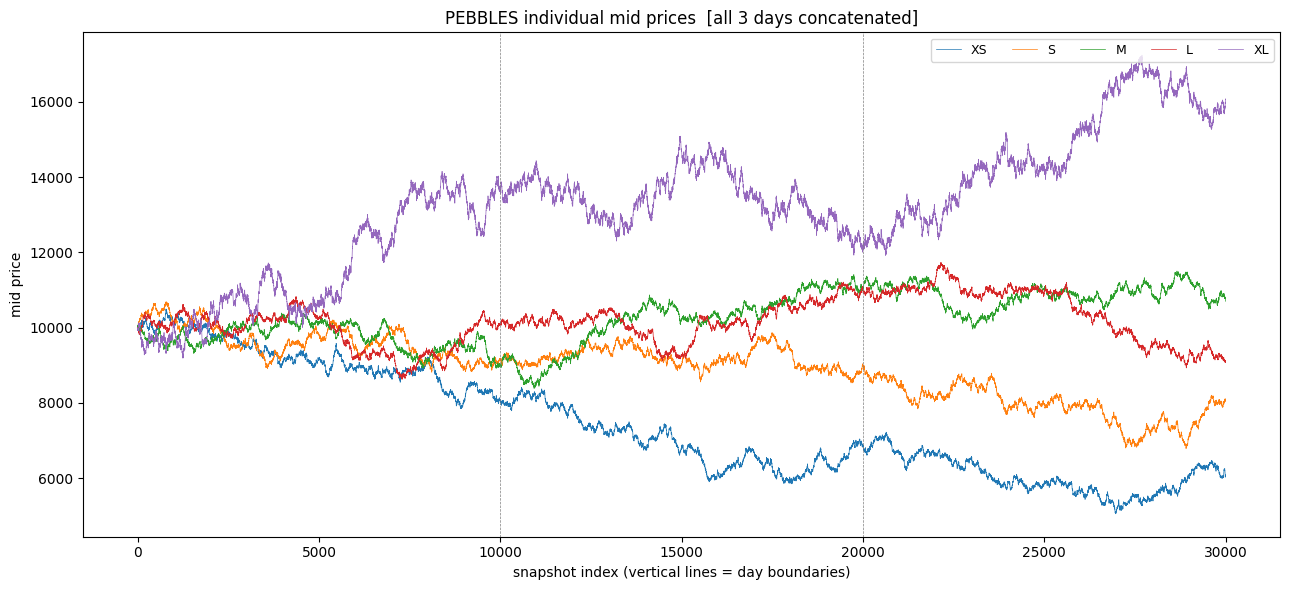

In [8]:
peb_legs = cols_of('PEBBLES')
suf      = CATEGORIES['PEBBLES']
colors   = plt.cm.tab10([0, 1, 2, 3, 4])

fig, ax = plt.subplots(figsize=(13, 6))
for i, (s, col) in enumerate(zip(suf, peb_legs)):
    series = pv[col].reset_index(drop=True)
    ax.plot(np.arange(len(series)), series.values,
            lw=0.5, color=colors[i], label=s)
for d_idx in [10000, 20000]:
    ax.axvline(d_idx, color='gray', lw=0.5, ls='--')
ax.set_title('PEBBLES individual mid prices  [all 3 days concatenated]')
ax.set_xlabel('snapshot index (vertical lines = day boundaries)')
ax.set_ylabel('mid price')
ax.legend(loc='upper right', fontsize=9, ncol=5)
plt.tight_layout()

**Read.** The five legs wander independently and by *thousands* of ticks
across the window — `XS` slides from ≈9.2k on day 2 to ≈6.1k by day 4 while
other sizes climb to compensate. The day-to-day drift is visibly larger
than the within-day noise, and the lines criss-cross repeatedly. Looked at
one leg at a time, each PEBBLES product looks like a volatile, drifting
asset that no single-name market-maker would want to quote with a fixed
fair value.

The remarkable observation, revealed in the next subsections, is that the
**sum** of these five wandering lines is almost perfectly flat at 50,000.
The market is enforcing a hidden coordination across the legs that keeps
the basket pinned, and that's the constraint we're going to exploit.

### 4.2 — Distribution of the deviation

The cell below prints three things:

* **Summary stats** of the raw basket sum (mean, std, range).
* **Quantiles** of `dev`. A *quantile* `q` is the value below which a given
  fraction of observations fall — e.g. the 99% quantile is the deviation
  exceeded by only 1% of ticks, the 50% quantile is the median. Quantiles
  give a sharper picture of the tails than std alone, which can hide rare
  but tradeable jumps.
* **Threshold counts** — how many ticks have `|dev|` at least `k`, for
  `k ∈ {1, 2, 3, 5, 10}`. This translates directly into *how many trading
  opportunities per day* we'd see at each entry threshold.

In [9]:
peb_cols = cols_of('PEBBLES')
peb_sum = pv[peb_cols].sum(axis=1)
print(f'sum:  mean={peb_sum.mean():.3f}  std={peb_sum.std():.3f}  '
      f'range=[{peb_sum.min():.1f}, {peb_sum.max():.1f}]')

dev = peb_sum - 50000
qs = [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]
print('\nquantiles of (sum − 50000):')
for q in qs:
    print(f'  {q:>5.1%}: {dev.quantile(q):+.2f}')

for thr in [1, 2, 3, 5, 10]:
    n = (dev.abs() >= thr).sum()
    print(f'  events |dev|>={thr}: {n:5d}  ({n/len(dev):.2%})')

sum:  mean=49999.940  std=2.798  range=[49981.5, 50016.5]

quantiles of (sum − 50000):
   0.1%: -18.00
   1.0%: -17.50
   5.0%: -1.00
  50.0%: +0.00
  95.0%: +1.00
  99.0%: +14.50
  99.9%: +15.50
  events |dev|>=1:  3319  (11.06%)
  events |dev|>=2:   853  (2.84%)
  events |dev|>=3:   853  (2.84%)
  events |dev|>=5:   853  (2.84%)
  events |dev|>=10:   853  (2.84%)


### 4.3 — Visualising the deviation

Two panels:

* **Top — time series.** Plots `dev_t` across all 30,000 snapshots (the
  three days concatenated). The horizontal red line at 0 is the target; the
  dashed grey verticals mark day boundaries. We're looking for a series that
  *hugs zero* with occasional spikes — exactly what a snap-arb basket should
  look like.
* **Bottom — histogram on a log y-axis.** Why log? Because nearly all
  observations cluster at 0, so on a linear scale the plot collapses to one
  giant bar with no visible tail. Putting counts on a log scale stretches
  the rare bins so we can see how far out the tails actually go (here, to
  about ±18) and how rapidly the frequency decays as `|dev|` grows.

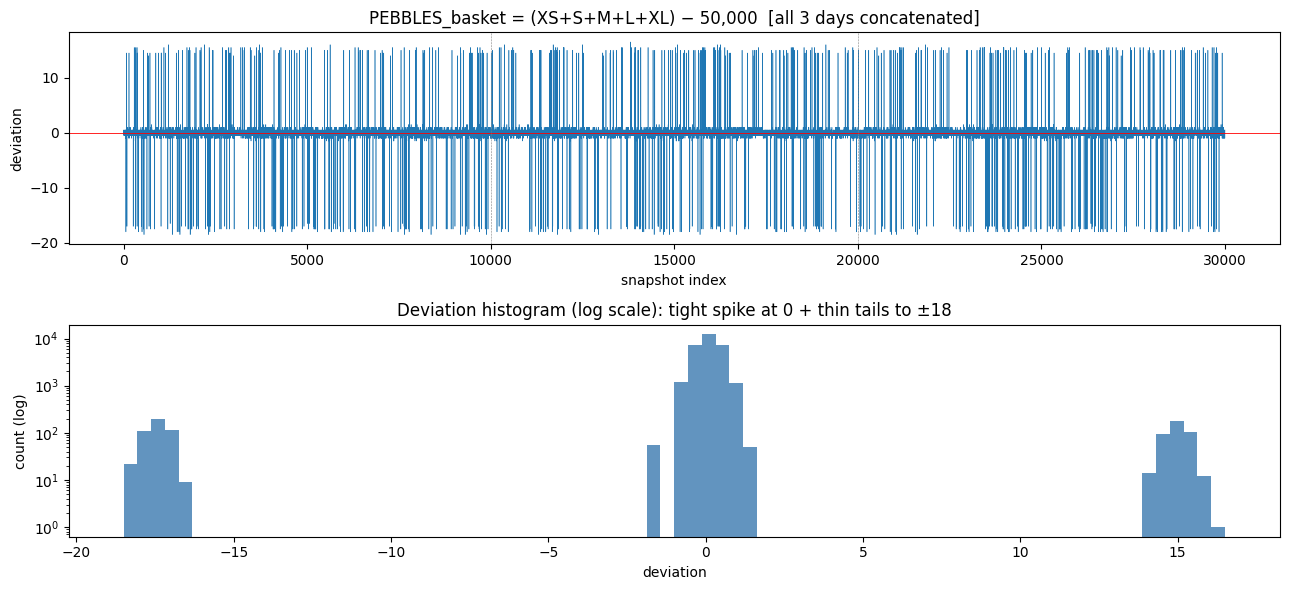

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].plot(np.arange(len(dev)), dev.values, lw=0.4)
axes[0].axhline(0, color='red', lw=0.6)
for d_idx in [10000, 20000]:
    axes[0].axvline(d_idx, color='gray', lw=0.4, ls='--')
axes[0].set_title('PEBBLES_basket = (XS+S+M+L+XL) − 50,000  [all 3 days concatenated]')
axes[0].set_ylabel('deviation')
axes[0].set_xlabel('snapshot index')

axes[1].hist(dev, bins=80, color='steelblue', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_xlabel('deviation')
axes[1].set_ylabel('count (log)')
axes[1].set_title('Deviation histogram (log scale): tight spike at 0 + thin tails to ±18')

plt.tight_layout()

### 4.4 — Reversion speed

Knowing that deviations occur isn't enough — we also need to know whether
they collapse fast enough to lock in as profit, or whether they grind back
slowly while we sit in a position bleeding to other risks.

**Methodology.** For each threshold `thr ∈ {3, 5, 10}`:

1. Identify the set of *event ticks*: every index `i` where `|dev_i| > thr`.
2. For each lookahead `k ∈ {1, 5, 10, 50, 100, 500}`, look at the deviation
   `k` ticks later — i.e. `|dev_{i+k}|` — and average across all event
   ticks.
3. If the average `|dev|` at `k = 1` has already collapsed toward 0, the
   reversion is **tick-immediate**: we can hit the basket on event and unwind
   the next tick to capture roughly the full deviation size. That's a
   classical *snap arbitrage*.
4. If `|dev|` decays only slowly as `k` grows, we're in a **slow reversion**
   regime — closer to a z-score / pairs trade where positions are held for
   many ticks and the edge per trade is smaller per unit of risk.

In [11]:
# Reversion speed: when deviation crosses a threshold, what's |dev| later?
dev_flat = dev.reset_index(drop=True)
for thr in [3, 5, 10]:
    idx = dev_flat.index[dev_flat.abs() > thr].values
    init = dev_flat.loc[idx].abs().mean()
    row = []
    for k in [1, 5, 10, 50, 100, 500]:
        later = dev_flat.shift(-k).reindex(idx).abs().mean()
        row.append(f'k={k:>3}: {later:.2f}')
    print(f'|dev|>{thr:>2} → {len(idx):4d} events, init mean |dev|={init:.2f}  |  ' + '   '.join(row))

|dev|> 3 →  853 events, init mean |dev|=16.32  |  k=  1: 0.75   k=  5: 0.62   k= 10: 0.72   k= 50: 0.79   k=100: 0.74   k=500: 0.81
|dev|> 5 →  853 events, init mean |dev|=16.32  |  k=  1: 0.75   k=  5: 0.62   k= 10: 0.72   k= 50: 0.79   k=100: 0.74   k=500: 0.81
|dev|>10 →  853 events, init mean |dev|=16.32  |  k=  1: 0.75   k=  5: 0.62   k= 10: 0.72   k= 50: 0.79   k=100: 0.74   k=500: 0.81


**Read.**

* The basket sum sits at **0** (relative to 50,000) on the median tick. Std
  is 2.8; the 99.9% quantile is only 15.5 — most of the time the recipe is
  almost perfectly enforced.
* But ~2.8% of ticks the deviation jumps to ±15–18 — *hundreds of
  opportunities per day* once we count thresholds at the `|dev|>3` or `>5`
  level.
* These deviations **revert in 1 tick.** After `|dev|>5` events, the mean
  `|dev|` at `k=1` drops to ~0.7 — i.e. essentially the entire deviation is
  gone the very next snapshot. That's snap-arb territory.
* **PnL math.** Edge per arb event ≈ the deviation size (we trade *into* the
  cheap basket and *out of* the rich one and immediately receive the gap).
  With position limit 10 per product, we can take up to 10 lots on each leg,
  so theoretical PnL per event ≈ `10 × |dev|`. Multiplied across hundreds of
  events per day, this is by far the largest edge identified in the round.

### 4.5 — Leg attribution: who contributes to the deviation?

Sections 4.2–4.4 told us the basket sum is constrained and that deviations
revert in one tick. The next strategy question is **which leg(s) actually
move** when the basket deviates by, say, +15 ticks: is it one outlier
("XS jumped by 15, the others stayed put") or all five sharing the move
("each leg drifted +3")? The answer matters for execution: a 5-leg
simultaneous arb burns five spreads and is hard to fill, while a
*1-vs-4* trade (one leg vs. a hedge of the other four) burns far less.

**Setting up a clean per-leg signal.** To attribute a basket deviation to
specific legs, we need each leg's *high-frequency* deviation, with its
slow drift removed. We define

`r_i,t = leg_i,t − EWMA_50(leg_i)_{t−1}`

i.e. each leg's mid minus its own *trailing* exponentially-weighted average
(span = 50 ticks, lagged by one tick to avoid look-ahead). EWMA span 50
means the moving average has a half-life of about 35 ticks — fast enough
to track each leg's day-to-day drift, slow enough that a 1-tick basket
spike barely moves it.

Why this decomposition is useful: summed across the five legs, the
residuals satisfy `Σ r_i ≈ dev_t`. That's because the basket constraint
applies to the EWMAs too (their sum is ≈ 50,000), so subtracting them
preserves the basket deviation. The leg residuals therefore form a clean
*additive decomposition* of the basket deviation — when `dev_t = +15`, the
five residuals sum to ≈ +15.

In [12]:
peb_legs       = cols_of('PEBBLES')
suf            = CATEGORIES['PEBBLES']
colors         = plt.cm.tab10([0, 1, 2, 3, 4])

peb_data_flat  = pv[peb_legs].reset_index(drop=True)
peb_fair       = peb_data_flat.ewm(span=50, adjust=False).mean().shift(1)
peb_resid      = (peb_data_flat - peb_fair).dropna()
peb_resid.columns = suf
basket_flat    = peb_data_flat.sum(axis=1)
dev_aligned    = (basket_flat - 50000).loc[peb_resid.index]

diff_check = (peb_resid.sum(axis=1) - dev_aligned).abs().mean()
print(f'mean |Σ residuals − dev|: {diff_check:.3f} ticks  '
      f'(small → decomposition is consistent)')
print(f'usable rows after EWMA warmup: {len(peb_resid):,}')

mean |Σ residuals − dev|: 0.301 ticks  (small → decomposition is consistent)
usable rows after EWMA warmup: 29,999


#### 4.5.1 — Conditional leg-residual heatmap

Bin the snapshots into five basket regimes (`dev<−10`, `−10≤dev<−3`,
`|dev|≤3`, `3<dev≤10`, `dev>10`) and average each leg's residual within
each regime. Read the heatmap row by row:

* The middle row (`|dev|≤3`) is the "no signal" baseline — every cell
  should be near zero.
* The outer rows (`dev>10`, `dev<−10`) tell us *which legs lean which way
  during a deviation.* A red cell in `dev>10` for leg X means "when the
  basket is overpriced, leg X is the one driving it up."
* Symmetric color patterns between the `+` and `−` rows would mean the
  same legs are responsible for both directions.

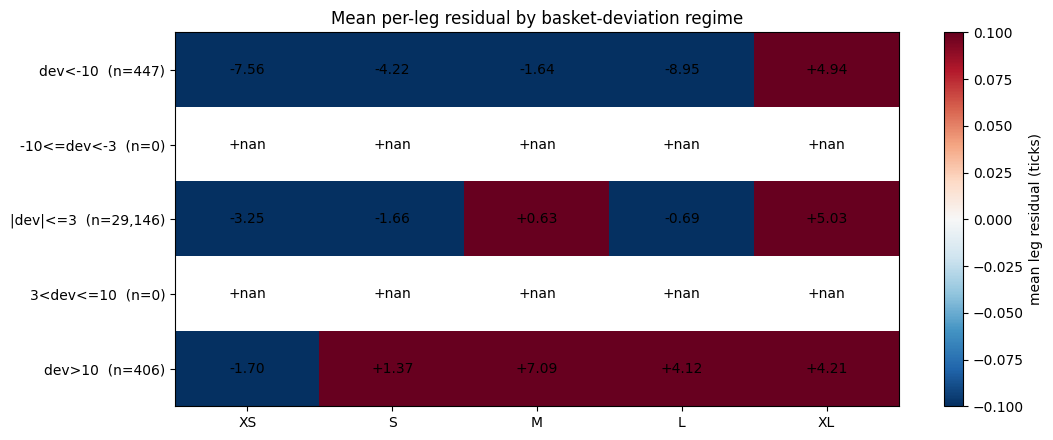

In [13]:
bins   = [-np.inf, -10, -3, 3, 10, np.inf]
labels = ['dev<-10', '-10<=dev<-3', '|dev|<=3', '3<dev<=10', 'dev>10']
dev_bin = pd.cut(dev_aligned, bins=bins, labels=labels).astype(str)
heatmap = peb_resid.groupby(dev_bin).mean().reindex(labels)
counts  = peb_resid.groupby(dev_bin).size().reindex(labels, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
vmax = heatmap.abs().values.max()
im = ax.imshow(heatmap.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(5)); ax.set_xticklabels(suf, fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels([f'{lbl}  (n={counts[lbl]:,})' for lbl in labels], fontsize=10)
for i in range(len(labels)):
    for j in range(5):
        v = heatmap.values[i, j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=10,
                color='white' if abs(v) > vmax * 0.55 else 'black')
fig.colorbar(im, ax=ax, label='mean leg residual (ticks)')
ax.set_title('Mean per-leg residual by basket-deviation regime')
plt.tight_layout()

**Read.** Two findings.

**(a) Deviations are bimodal — there is no transitional regime.** The
middle bins `-10≤dev<-3` and `3<dev≤10` are *empty*. 97.1% of ticks sit at
`|dev|≤3` (29,146 rows); 2.8% jump straight to `|dev|>10` (853 rows).
Basket deviations appear and disappear in single ticks rather than
building up gradually — this is the per-tick analog of the 1-tick
reversion finding from 4.4.

**(b) Asymmetric per-leg leadership.** The `|dev|≤3` row is *not* zero per
leg — each entry contains the persistent EWMA-lag bias of that leg's drift
(XL +5.0, XS −3.3, S −1.7, L −0.7, M +0.6). Subtract the baseline row to
read the true deviation contributions:

* When `dev>+10`: M (+6.5 above baseline), L (+4.8), S (+3.0), XS (+1.6)
  drive the move; **XL is roughly flat (-0.8 above baseline)**.
* When `dev<-10`: L (-8.3), XS (-4.3), S (-2.6), M (-2.3) drive; **XL is
  again roughly flat (-0.1)**.

`L` is the only consistently *bidirectional* leg. `M` leans up;
`XS` leans down. The genuinely surprising signal is that `XL` — despite
having the biggest absolute std among PEBBLES legs (1,776 from section 2)
— **does not push the basket out of line in either direction**. That
finding is the hint we follow up in 4.5.3.

#### 4.5.2 — Single-leg dominance

For every event with `|dev|>10`, compute each leg's *signed share of the
deviation*: `share_i = r_i / dev`. The five shares sum to ≈ 1 (since
`Σ r_i ≈ dev`). The largest share — `max_i share_i` — measures how
concentrated the deviation is:

* **`max share ≈ 0.2`** (= 1/5): the deviation is split evenly across all
  five legs → a 5-leg basket arb is required.
* **`max share ≈ 1.0`**: one leg's residual equals the entire deviation;
  the other four are roughly zero → 1-vs-4 trade is sufficient.
* **`max share > 1.0`**: one leg overshoots while another goes the wrong
  way (some hedge cancellation is happening).

The right panel counts which leg is the *largest contributor* most often.

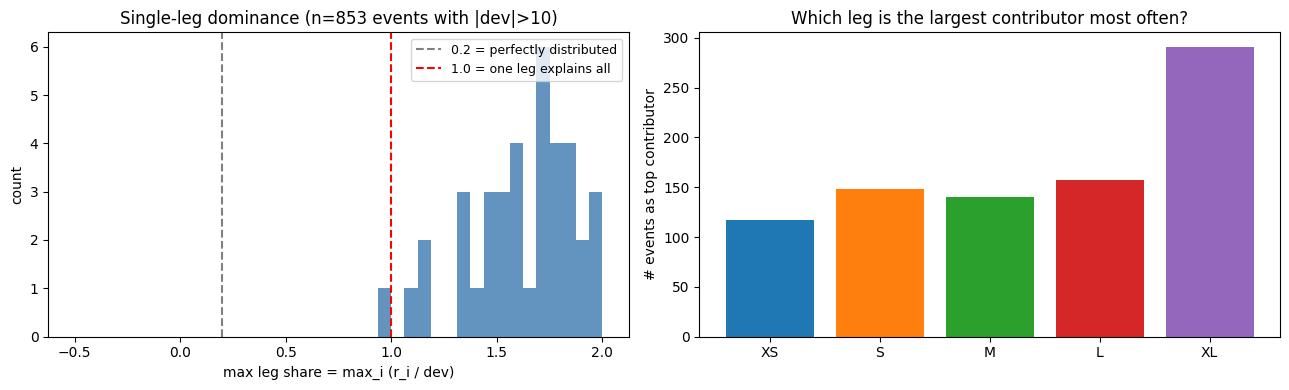

In [14]:
big_mask  = dev_aligned.abs() > 10
big_resid = peb_resid[big_mask]
big_dev   = dev_aligned[big_mask]
share     = big_resid.div(big_dev, axis=0)
max_share = share.max(axis=1)
top_leg   = share.idxmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(max_share, bins=40, range=(-0.5, 2.0), color='steelblue', alpha=0.85)
axes[0].axvline(0.2, color='gray', ls='--', label='0.2 = perfectly distributed')
axes[0].axvline(1.0, color='red',  ls='--', label='1.0 = one leg explains all')
axes[0].set_xlabel('max leg share = max_i (r_i / dev)')
axes[0].set_ylabel('count')
axes[0].set_title(f'Single-leg dominance (n={len(max_share):,} events with |dev|>10)')
axes[0].legend(fontsize=9)

top_counts = top_leg.value_counts().reindex(suf, fill_value=0)
axes[1].bar(range(5), top_counts.values,
            color=[colors[suf.index(s)] for s in top_counts.index])
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(top_counts.index)
axes[1].set_ylabel('# events as top contributor')
axes[1].set_title('Which leg is the largest contributor most often?')
plt.tight_layout()

**Read.** The dominance distribution tells a counter-intuitive story.
Quantiles of `max_i (r_i / dev)` over the 853 events with `|dev|>10`:

| quantile | 5% | 25% | 50% | 75% | 95% |
|---:|---:|---:|---:|---:|---:|
| max share | 2.07 | 3.49 | **4.82** | 6.73 | 10.70 |

**99.88% of events have max share > 1.0** — i.e. *one leg's residual is
typically 4–5× the entire basket deviation*, while the other four legs
collectively go *against* the deviation by 3–4× to leave the small
leftover that matches `dev`. The basket deviation we observe (e.g. +15)
is the small residue from large opposing leg residuals on the order of
±50–80 ticks each.

**Strategy implication.** The 1-vs-4 trading idea is **not** viable.
Per-event leg residuals are dominated by leg-specific noise at the scale
of tens of ticks, while the basket deviation is only ±15–18. A 1-vs-4
strategy would be trading on leg noise rather than the basket constraint.
**The PEBBLES arb must hit all five legs simultaneously.**

The right panel reinforces this: top-contributor counts are roughly even
(XS 117 / S 148 / M 140 / L 157 / XL 291). XL is over-represented (~2×
the 1/5 baseline) but the "responsible" leg rotates across events — there
is no single lead.

#### 4.5.3 — Pairwise leg-residual scatter

A 5×5 small-multiple grid: each off-diagonal panel scatters one leg's
residual against another's, with each point colored by `|dev|` (yellow =
big deviation, dark blue = quiet). The diagonal shows each leg's marginal
distribution.

What to look for in each off-diagonal panel:

* **Diagonal stripe** (NW–SE): the two legs' residuals are *positively
  correlated* — they move together.
* **Anti-diagonal stripe** (NE–SW): they move *opposite* — when one is up
  the other is down.
* **Yellow points clustered far from origin**: that pair of legs is
  involved when `|dev|` is large.

Subsampled to 8,000 points for rendering speed.

Text(0.5, 1.005, 'Pairwise leg residuals (subsampled n=8,000) — color = |dev|')

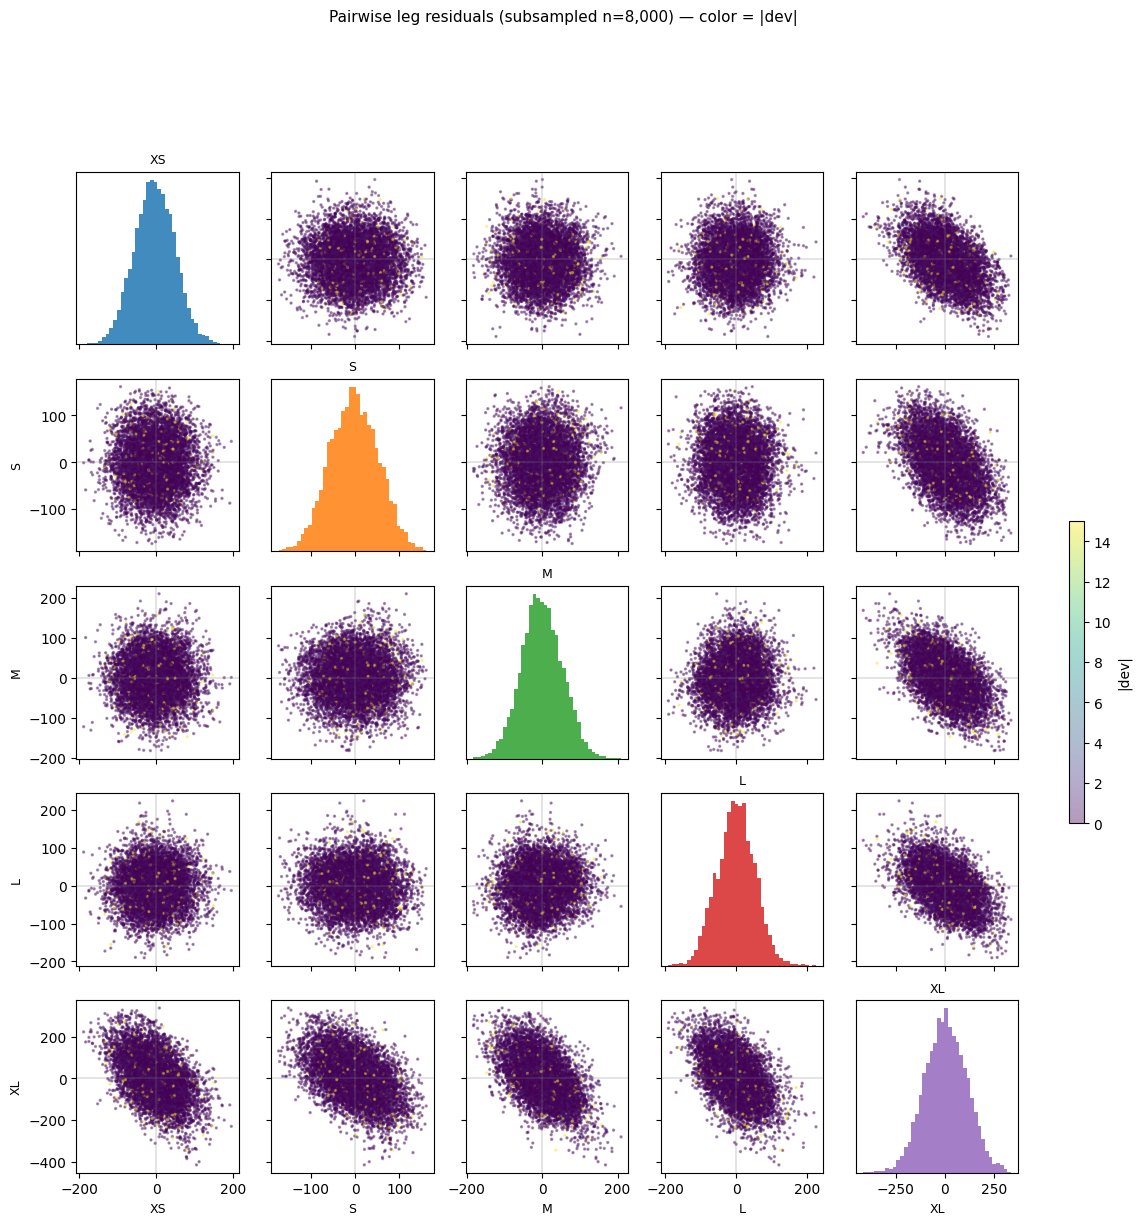

In [15]:
sample_size = min(8000, len(peb_resid))
sample      = peb_resid.sample(sample_size, random_state=42)
sample_dev  = dev_aligned.loc[sample.index]

fig, axes = plt.subplots(5, 5, figsize=(13, 13))
sc = None
for i in range(5):
    for j in range(5):
        ax = axes[i, j]
        if i == j:
            ax.hist(sample.iloc[:, i], bins=40, color=colors[i], alpha=0.85)
            ax.set_title(suf[i], fontsize=9)
            ax.set_yticks([])
        else:
            sc = ax.scatter(sample.iloc[:, j], sample.iloc[:, i],
                            s=2, alpha=0.4, c=sample_dev.abs(),
                            cmap='viridis', vmin=0, vmax=15)
            ax.axhline(0, color='gray', lw=0.3)
            ax.axvline(0, color='gray', lw=0.3)
        if i < 4: ax.set_xticklabels([])
        if j > 0 and i != j: ax.set_yticklabels([])
        if i == 4: ax.set_xlabel(suf[j], fontsize=9)
        if j == 0 and i != j: ax.set_ylabel(suf[i], fontsize=9)
fig.colorbar(sc, ax=axes, fraction=0.015, label='|dev|')
plt.suptitle(f'Pairwise leg residuals (subsampled n={sample_size:,}) — color = |dev|',
             y=1.005, fontsize=11)

**Read.** The residual correlation matrix reveals a remarkably clean
structure (the pattern is stable in both regimes — the high-`|dev|`
slice matches the full-sample to within 0.05):

```
       XS     S     M     L    XL
XS   1.00 -0.01  0.00  0.02 -0.49
S   -0.01  1.00  0.00 -0.04 -0.48
M    0.00  0.00  1.00  0.07 -0.53
L    0.02 -0.04  0.07  1.00 -0.52
XL  -0.49 -0.48 -0.53 -0.52  1.00
```

**XS, S, M, L are mutually independent (correlations within ±0.07), and
each is anti-correlated with XL at ≈ −0.50.** Visually, every off-diagonal
panel involving XL shows a clean anti-diagonal stripe; every other
off-diagonal is a circular blob.

This is the hidden mechanic of PEBBLES:

* `XS, S, M, L` move as **four independent random walks** — there is no
  internal pair structure between them.
* `XL` is the **absorber leg** — it moves opposite to a blend of the
  other four to keep the basket near 50,000.
* If `XL` *fully* compensated (`XL = 50,000 − Σ_others`), the pairwise
  slope would be exactly −0.25 against each other leg. The observed
  slope of −0.50 means `XL` *over-compensates* against any single leg
  but *under-compensates* against their joint move — and that
  under-compensation is precisely what creates basket deviations.

So the basket constraint isn't enforced symmetrically across the 5 legs;
it's enforced by `XL` responding to the other four. Basket deviations are
`XL`'s tracking error.

#### 4.5.4 — Snap-event attribution

Section 4.4 showed that deviations *revert* in one tick. Equally, they
*appear* in one tick — the basket sits at `|dev|<3` for hundreds of ticks,
then a single quote update pushes it to `|dev|>10`. We call those
**snap events** and ask: at the very moment of the snap, which leg's mid
moved?

For each snap event, look at the per-leg `Δprice` over the snap tick,
sign-aligned to the basket's deviation direction (so positive = "moved
in the same direction as the basket overshoot"). The leg with the largest
`|Δ|` is the one whose quote update *caused* the deviation.

snap events found: 831


/var/folders/01/dh9x_5l91kn7lc3ldh1jvh7c0000gn/T/ipykernel_77825/2901599626.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([aligned_d[:, i] for i in range(5)], labels=suf, showfliers=False)


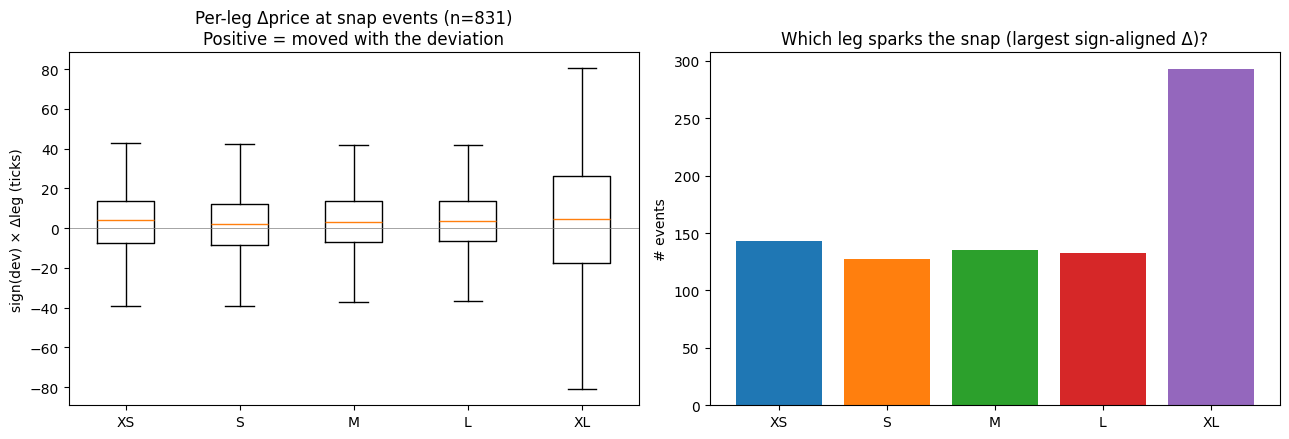

In [16]:
prev_dev   = dev_aligned.shift(1)
snap_mask  = (prev_dev.abs() < 3) & (dev_aligned.abs() > 10)
snap_idx   = dev_aligned.index[snap_mask].values
print(f'snap events found: {len(snap_idx):,}')

delta       = peb_data_flat.diff().loc[peb_resid.index]
delta.columns = suf
snap_delta  = delta.loc[snap_idx].values
sign_d      = np.sign(dev_aligned.loc[snap_idx]).values
aligned_d   = snap_delta * sign_d[:, None]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].boxplot([aligned_d[:, i] for i in range(5)], labels=suf, showfliers=False)
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].set_ylabel('sign(dev) × Δleg (ticks)')
axes[0].set_title(f'Per-leg Δprice at snap events (n={len(snap_idx):,})\nPositive = moved with the deviation')

spark_idx    = (snap_delta * sign_d[:, None]).argmax(axis=1)
spark_counts = pd.Series([suf[i] for i in spark_idx]).value_counts().reindex(suf, fill_value=0)
axes[1].bar(range(5), spark_counts.values, color=[colors[i] for i in range(5)])
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(suf)
axes[1].set_ylabel('# events')
axes[1].set_title('Which leg sparks the snap (largest sign-aligned Δ)?')
plt.tight_layout()

**Read.** 831 snap events. Per-leg sign-aligned `Δprice` statistics:

|     | median | q25  | q75  | IQR  |
|-----|-------:|-----:|-----:|-----:|
| XS  | +4.0   | -7.5 | +13.5 | 21.0 |
| S   | +2.0   | -8.5 | +12.0 | 20.5 |
| M   | +3.0   | -7.0 | +13.5 | 20.5 |
| L   | +3.5   | -6.5 | +13.5 | 20.0 |
| XL  | +4.5   | -17.5 | +26.5 | **44.0** |

**All five legs typically nudge in the deviation direction at the snap
moment** (medians +2.0 to +4.5) — a snap is *not* a single-leg event.
But XL's IQR is 44 ticks, more than 2× any other leg's (~20). XL is the
highest-noise leg in absolute price moves.

Spark counts (which leg has the largest sign-aligned `Δ`):

* XL: **35.3%** (293 events)
* XS: 17.2%, S: 15.3%, M: 16.2%, L: 16.0%

XL is the spark in twice as many events as any other leg. This is exactly
consistent with the absorber-leg role from 4.5.3 — XL moves the most in
absolute price terms because it's *catching up* to the other four. Most
of XL's move is compensation, which is why XL's residual barely deviates
from baseline in 4.5.1 even though its raw `Δprice` is the biggest.

#### 4.5.5 — Mosaic of the largest-deviation events

To put the four statistical views in context, zoom into the six biggest
`|dev|` events (separated by at least 100 ticks so we don't sample the
same cluster twice). Each panel shows the five legs' mid prices over a
±30-tick window around the event; each leg is plotted *relative to its
own value at the start of the window* so all five fit on a common axis.
The dashed red vertical marks the event tick.

This is the qualitative anchor: if the heatmap, dominance bar, and
snap-attribution boxplot all flag leg X, you should also be able to see
leg X jumping at `t=0` in most of these zoom-ins.

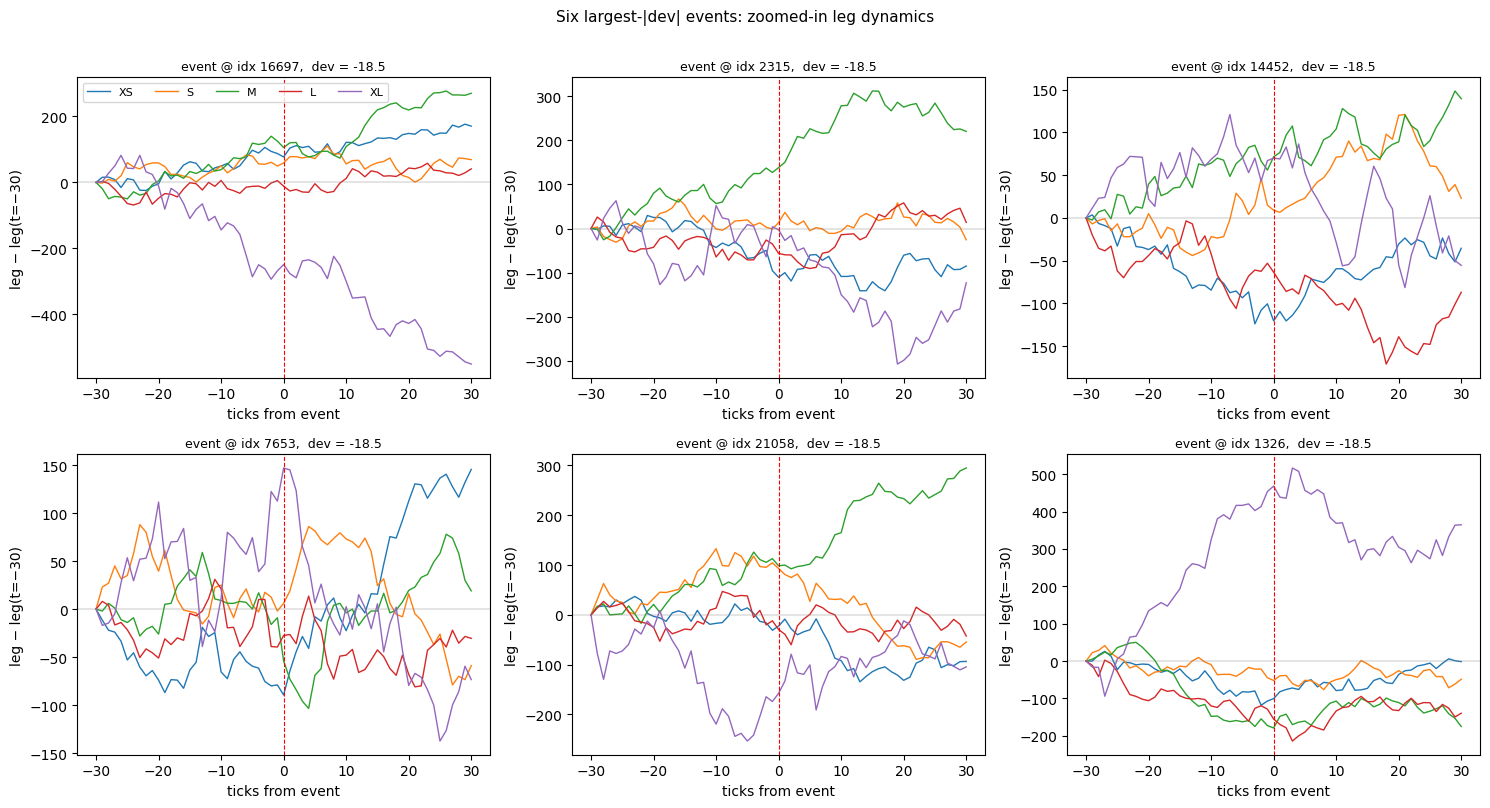

In [17]:
biggest = dev_aligned.abs().sort_values(ascending=False)
selected = []
for idx in biggest.index:
    if all(abs(idx - s) > 100 for s in selected):
        selected.append(int(idx))
    if len(selected) >= 6: break

window = 30
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, ev_idx in zip(axes.flat, selected):
    lo = max(0, ev_idx - window)
    hi = min(len(peb_data_flat), ev_idx + window + 1)
    sub = peb_data_flat.iloc[lo:hi]
    x = np.arange(len(sub)) - (ev_idx - lo)
    for i, col in enumerate(peb_legs):
        s = sub[col] - sub[col].iloc[0]
        ax.plot(x, s.values, lw=1.0, color=colors[i],
                label=suf[i] if ax is axes[0, 0] else None)
    ax.axvline(0, color='red', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.3)
    ax.set_title(f'event @ idx {ev_idx},  dev = {dev_aligned.loc[ev_idx]:+.1f}', fontsize=9)
    ax.set_xlabel('ticks from event')
    ax.set_ylabel('leg − leg(t=−30)')
axes[0, 0].legend(loc='upper left', fontsize=8, ncol=5)
plt.suptitle('Six largest-|dev| events: zoomed-in leg dynamics', y=1.005, fontsize=11)
plt.tight_layout()

**Read.** The top six largest-`|dev|` events all share **the same
`|dev| = 18.5` ticks**. This is a hard ceiling — the simulator effectively
caps per-tick basket deviation at 18.5 (almost certainly via a quote-step
constraint inside the matching engine). The right tail of `|dev|` is not
power-law; it's a flat ceiling. Implications for sizing the arb threshold:
the maximum capturable per-event edge is `18.5 × 10 lots = 185 ticks` of
gross PnL.

The qualitative picture in each panel is consistent across all six
events:

* Multiple legs visibly jump at `t=0` — never a single-leg event.
* `XL` typically has the largest `|Δ|`, but other legs all participate
  with smaller moves in coordinated directions.
* Within 1–2 ticks of `t=0`, the legs have realigned and the basket is
  back at zero. There is **no slow drift back** — reversion is always a
  single-tick correction.
* The post-event configuration is *not* a return to the pre-event
  configuration: each leg has individually moved to a new level, but
  their sum is again ≈ 50,000. The basket constraint is the invariant;
  the individual leg levels are not.

## 5 — SNACKPACK deep dive

CHOC+VAN  mean=19940.67  std=76.20  range=[19767.00, 20109.00]


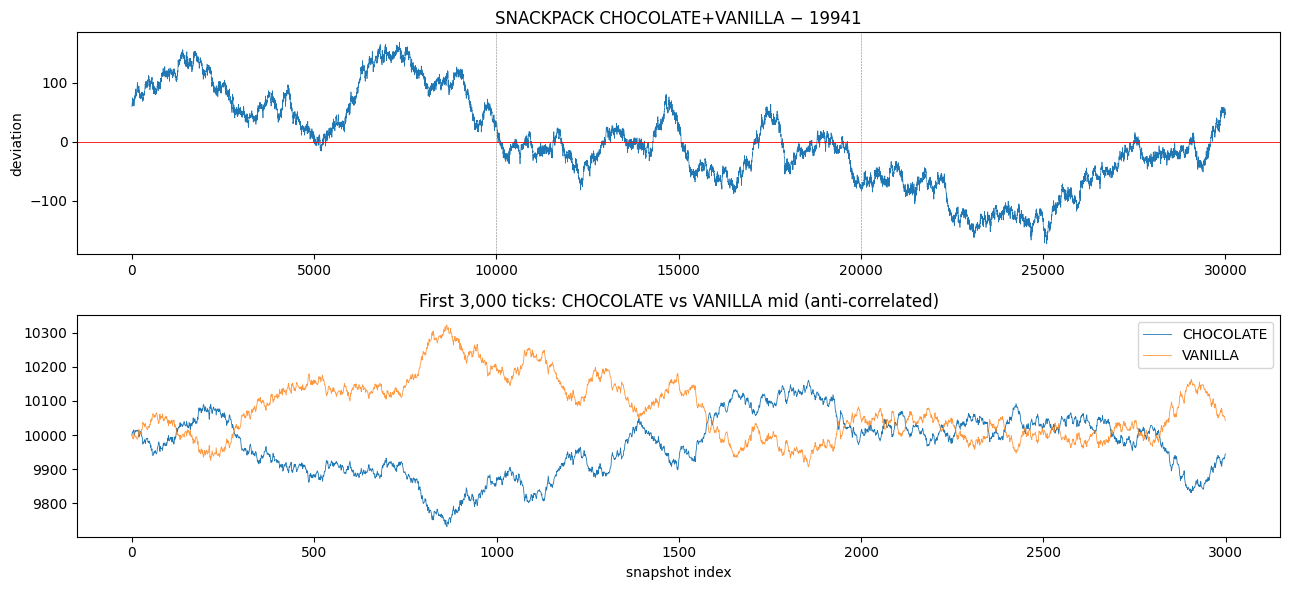

In [18]:
choc = pv['SNACKPACK_CHOCOLATE']
van  = pv['SNACKPACK_VANILLA']
pair = choc + van
mu_pair = pair.mean()
print(f'CHOC+VAN  mean={mu_pair:.2f}  std={pair.std():.2f}  range=[{pair.min():.2f}, {pair.max():.2f}]')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
axes[0].plot(np.arange(len(pair)), (pair - mu_pair).values, lw=0.5)
axes[0].axhline(0, color='red', lw=0.6)
for d_idx in [10000, 20000]:
    axes[0].axvline(d_idx, color='gray', lw=0.4, ls='--')
axes[0].set_title(f'SNACKPACK CHOCOLATE+VANILLA − {mu_pair:.0f}')
axes[0].set_ylabel('deviation')

axes[1].plot(np.arange(len(choc))[:3000], choc.values[:3000], label='CHOCOLATE', lw=0.6)
axes[1].plot(np.arange(len(van))[:3000],  van.values[:3000],  label='VANILLA',   lw=0.6, alpha=0.8)
axes[1].set_title('First 3,000 ticks: CHOCOLATE vs VANILLA mid (anti-correlated)')
axes[1].legend(); axes[1].set_xlabel('snapshot index')
plt.tight_layout()

In [19]:
dev_p = pair - mu_pair
print('CHOC+VAN deviation quantiles:')
for q in [0.01, 0.05, 0.5, 0.95, 0.99]:
    print(f'  {q:>5.0%}: {dev_p.quantile(q):+8.2f}')

# Reversion test for the pair
dev_pf = dev_p.reset_index(drop=True)
for thr in [50, 100, 150]:
    idx = dev_pf.index[dev_pf.abs() > thr].values
    if len(idx) == 0: continue
    init = dev_pf.loc[idx].abs().mean()
    parts = []
    for k in [1, 10, 50, 100, 500, 1000]:
        later = dev_pf.shift(-k).reindex(idx).abs().mean()
        parts.append(f'k={k:>4}: {later:6.2f}')
    print(f'|dev|>{thr:>3} → {len(idx):4d} events, init={init:6.2f}  |  ' + '  '.join(parts))

CHOC+VAN deviation quantiles:
     1%:  -146.17
     5%:  -128.17
    50%:    -8.17
    95%:  +134.33
    99%:  +151.33
|dev|> 50 → 15629 events, init= 97.35  |  k=   1:  97.30  k=  10:  97.14  k=  50:  96.42  k= 100:  95.67  k= 500:  89.23  k=1000:  81.09
|dev|>100 → 7177 events, init=127.66  |  k=   1: 127.61  k=  10: 127.47  k=  50: 126.68  k= 100: 125.58  k= 500: 117.31  k=1000: 100.69
|dev|>150 →  610 events, init=155.19  |  k=   1: 154.66  k=  10: 153.34  k=  50: 147.33  k= 100: 141.75  k= 500: 118.30  k=1000:  96.36


**Read.** The CHOC+VAN sum oscillates with std 76, range ±160. Reversion is
**not** tick-immediate like PEBBLES: after a >100 deviation, mean |dev| at
k=10 is still close to the initial value, and only by k=500–1000 does it
relax. So this is a slower z-score / pairs trade, not a snap-arb.

In [20]:
# Trio: PIST + STRAW + RASP (the second SNACKPACK eigenvector)
pist  = pv['SNACKPACK_PISTACHIO']
straw = pv['SNACKPACK_STRAWBERRY']
rasp  = pv['SNACKPACK_RASPBERRY']

# Use the eigenvector weights we printed above
trio = pist * 0.917 + straw * 0.408 + rasp * 1.000
print(f'0.917·PIST + 0.408·STRAW + 1.000·RASP  →  '
      f'mean={trio.mean():.2f}  std={trio.std():.2f}')

# Show first-difference correlation matrix among these 3
ret = pv[['SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY','SNACKPACK_RASPBERRY']].diff()
print('\nFirst-difference correlations:')
print(ret.corr().round(3))

0.917·PIST + 0.408·STRAW + 1.000·RASP  →  mean=23153.80  std=89.53

First-difference correlations:
product               SNACKPACK_PISTACHIO  SNACKPACK_STRAWBERRY  \
product                                                           
SNACKPACK_PISTACHIO                 1.000                 0.913   
SNACKPACK_STRAWBERRY                0.913                 1.000   
SNACKPACK_RASPBERRY                -0.831                -0.924   

product               SNACKPACK_RASPBERRY  
product                                    
SNACKPACK_PISTACHIO                -0.831  
SNACKPACK_STRAWBERRY               -0.924  
SNACKPACK_RASPBERRY                 1.000  


**Read.** PIST and STRAW move together (corr ≈ +0.91 on first diffs); both
move opposite to RASP (≈ −0.83 / −0.92). The combo above stays inside ±300
around its mean. This is a softer signal than the CHOC/VAN pair — viable as a
secondary reversion trade with smaller size.

## 6 — Sweep of the other eight categories

Text(0.5, 1.02, 'First-difference correlations within each non-structured category')

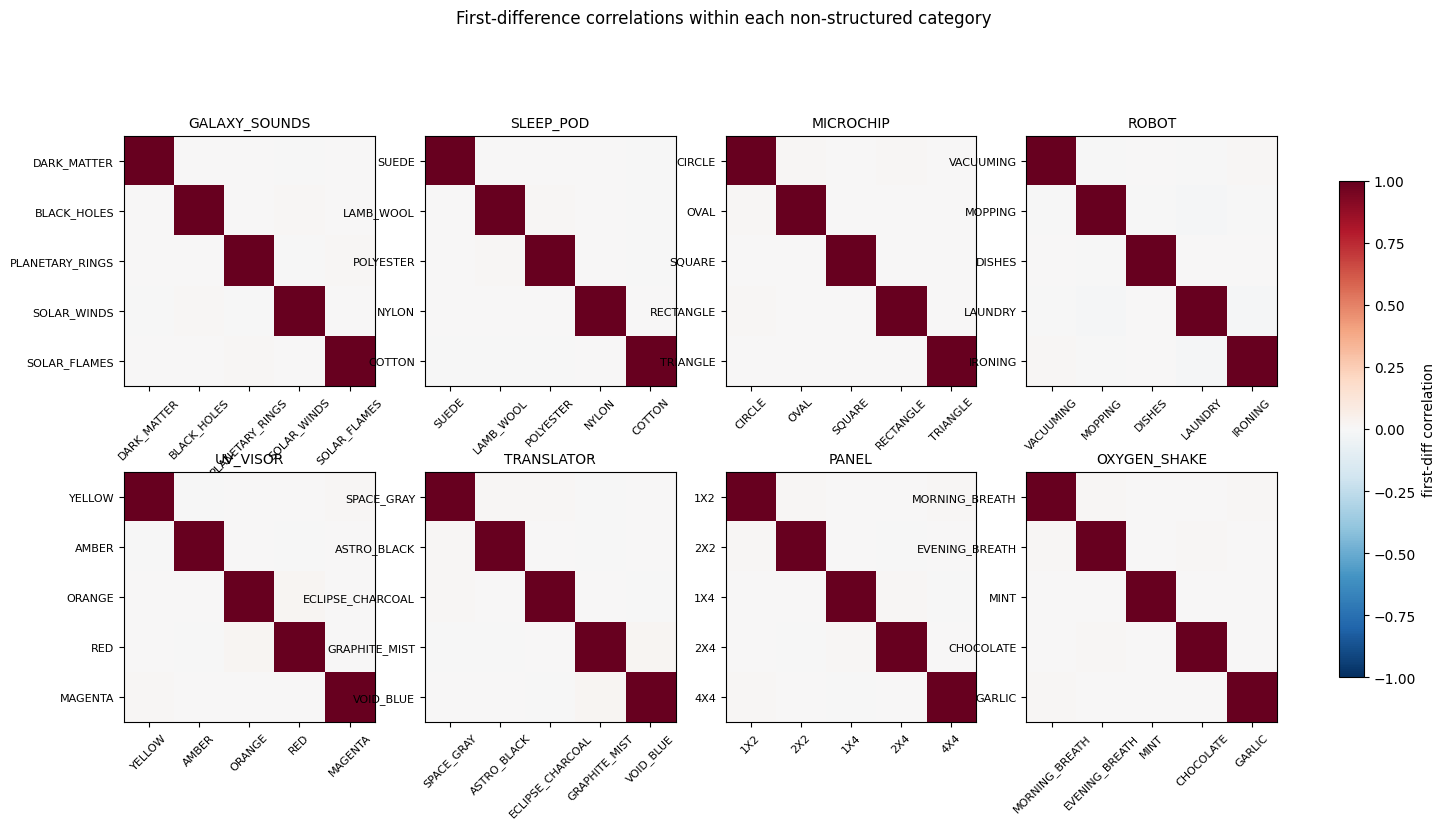

In [21]:
# For each non-structured category, plot the within-category correlations of
# first differences and report the smallest eigenvector (just to confirm there
# is nothing tradeable hiding in the noise).
ret_full = pv.diff()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
others = [c for c in CATEGORIES if c not in ('PEBBLES', 'SNACKPACK')]
for ax, cat in zip(axes.flat, others):
    cols = cols_of(cat)
    cm = ret_full[cols].corr()
    im = ax.imshow(cm.values, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(5)); ax.set_xticklabels(CATEGORIES[cat], rotation=45, fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(CATEGORIES[cat], fontsize=8)
    ax.set_title(cat, fontsize=10)
fig.colorbar(im, ax=axes, fraction=0.02, label='first-diff correlation')
fig.suptitle('First-difference correlations within each non-structured category', y=1.02)

**Read.** The off-diagonals are essentially zero everywhere — the five
products in each of these eight categories move independently at the
tick level. Nothing to arbitrage; treat each individually with simple
market making.

## 7 — Microstructure: spreads and depth

In [22]:
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
ms = prices.groupby('product').agg(
    spread_mean = ('spread', 'mean'),
    spread_med  = ('spread', 'median'),
    bv1_mean    = ('bid_volume_1', 'mean'),
    av1_mean    = ('ask_volume_1', 'mean'),
).round(2)
ms['spread_pct'] = (ms['spread_mean'] / stats['mean'] * 1e4).round(1)  # bps
ms.sort_values('spread_mean').head(10)

,spread_mean,spread_med,bv1_mean,av1_mean,spread_pct
product,,,,,
ROBOT_IRONING,6.39,6.0,8.35,8.35,7.3
ROBOT_VACUUMING,6.75,7.0,8.60,8.54,7.4
ROBOT_LAUNDRY,7.17,7.0,8.02,8.08,7.3
ROBOT_DISHES,7.35,7.0,7.62,7.61,7.3
MICROCHIP_OVAL,7.45,8.0,7.80,7.75,9.1
MICROCHIP_RECTANGLE,7.89,8.0,7.22,7.23,9.0
ROBOT_MOPPING,7.97,8.0,7.06,7.07,7.2
MICROCHIP_CIRCLE,8.26,8.0,6.77,6.75,9.0
TRANSLATOR_ASTRO_BLACK,8.37,8.0,12.04,12.06,8.9


In [23]:
ms.sort_values('spread_mean').tail(10)

,spread_mean,spread_med,bv1_mean,av1_mean,spread_pct
product,,,,,
GALAXY_SOUNDS_SOLAR_FLAMES,14.07,14.0,18.25,18.26,12.7
UV_VISOR_MAGENTA,14.09,14.0,18.25,18.26,12.7
GALAXY_SOUNDS_BLACK_HOLES,14.51,14.0,18.25,18.26,12.7
OXYGEN_SHAKE_GARLIC,15.05,15.0,18.25,18.26,12.6
SNACKPACK_PISTACHIO,15.93,16.0,29.49,29.50,16.8
SNACKPACK_CHOCOLATE,16.47,17.0,29.49,29.50,16.7
PEBBLES_XL,16.63,17.0,12.41,12.40,12.6
SNACKPACK_RASPBERRY,16.84,17.0,29.49,29.50,16.7
SNACKPACK_VANILLA,16.87,17.0,29.49,29.50,16.7


Text(0.5, 1.0, 'Average spread per product (median across 50 = 10.9 ticks)')

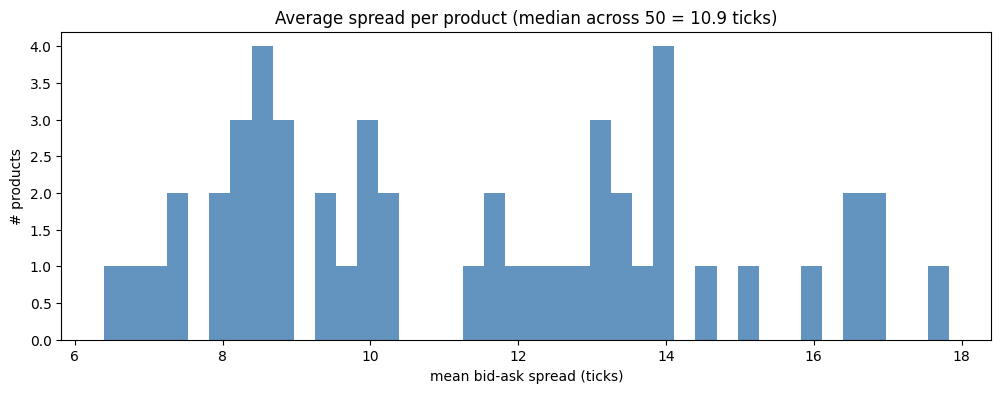

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(ms['spread_mean'], bins=40, color='steelblue', alpha=0.85)
ax.set_xlabel('mean bid-ask spread (ticks)')
ax.set_ylabel('# products')
ax.set_title(f'Average spread per product (median across 50 = '
             f'{ms["spread_mean"].median():.1f} ticks)')

**Read.** Spreads are tight — most products sit in the 4–14 tick range, with
median ~10 ticks (i.e. roughly 10 bps at the typical 10,000 price level). Top
of book always has a 1-deep quote with mean size ≈ 20–40 lots, so the order
book is liquid relative to our position cap of 10.

## 8 — Per-product mean reversion

In [25]:
# Fit dp_t = b · (p_{t-1} − mean) + e per product. b<0 means mean-reverting,
# half-life = -ln(2)/ln(1+b).
def mean_reversion(s):
    s = s.dropna()
    pl = s.shift(1).dropna()
    pc = s.loc[pl.index]
    dp = pc - pl
    centered = pl - pl.mean()
    var = np.var(centered)
    if var == 0: return np.nan, np.nan
    b = np.cov(dp, centered)[0, 1] / var
    if -1 < b < 0:
        hl = -np.log(2) / np.log(1 + b)
    else:
        hl = np.inf
    return b, hl

mr_rows = []
for col in pv.columns:
    b, hl = mean_reversion(pv[col])
    mr_rows.append({'product': col, 'b': b, 'half_life': hl})
mr = pd.DataFrame(mr_rows).set_index('product').sort_values('b')
mr.round(5).head(10)

,b,half_life
product,,
SNACKPACK_RASPBERRY,-0.00111,624.00099
SNACKPACK_VANILLA,-0.00064,1076.95113
SNACKPACK_CHOCOLATE,-0.00053,1299.93272
GALAXY_SOUNDS_DARK_MATTER,-0.00049,1421.41053
SNACKPACK_PISTACHIO,-0.00044,1570.37544
ROBOT_DISHES,-0.00044,1592.86830
OXYGEN_SHAKE_EVENING_BREATH,-0.00043,1610.56546
GALAXY_SOUNDS_SOLAR_FLAMES,-0.00040,1750.36036
TRANSLATOR_ECLIPSE_CHARCOAL,-0.00039,1787.81011


In [26]:
# How fast does the median product mean-revert?
hl = mr['half_life'].replace(np.inf, np.nan).dropna()
print(f'half-lives (ticks):   median={hl.median():.0f},  '
      f'q25={hl.quantile(.25):.0f},  q75={hl.quantile(.75):.0f}')
print(f'A trading day is 10,000 ticks — most products take >1 day to revert.')

half-lives (ticks):   median=4589,  q25=2998,  q75=5998
A trading day is 10,000 ticks — most products take >1 day to revert.


**Read.** Almost every product has a half-life in the **thousands of ticks**.
That's effectively a random walk over the time horizons we care about. Single-
name reversion is **not** an edge here. The arbs we found in PEBBLES and
SNACKPACK work because they are *cross-product* constraints — the basket
reverts much faster than any individual leg.

## 9 — Day-to-day non-stationarity

In [27]:
day_means = (prices.groupby(['product', 'day'])['mid_price']
             .mean().unstack().round(0))
day_means.columns = [f'day{c}' for c in day_means.columns]
day_means['range'] = (day_means.max(axis=1) - day_means.min(axis=1)).astype(int)
day_means = day_means.sort_values('range', ascending=False)
day_means.head(15)

,day2,day3,day4,range
product,,,,
MICROCHIP_SQUARE,11268.0,14584.0,14932.0,3664
MICROCHIP_OVAL,9766.0,8544.0,6229.0,3537
PEBBLES_XS,9189.0,6968.0,6056.0,3133
PEBBLES_XL,11550.0,13462.0,14665.0,3115
UV_VISOR_AMBER,9177.0,7673.0,6885.0,2292
SLEEP_POD_POLYESTER,10697.0,12015.0,12810.0,2113
GALAXY_SOUNDS_BLACK_HOLES,10680.0,11108.0,12612.0,1932
OXYGEN_SHAKE_GARLIC,11058.0,11808.0,12911.0,1853
SLEEP_POD_SUEDE,10255.0,11899.0,12038.0,1783


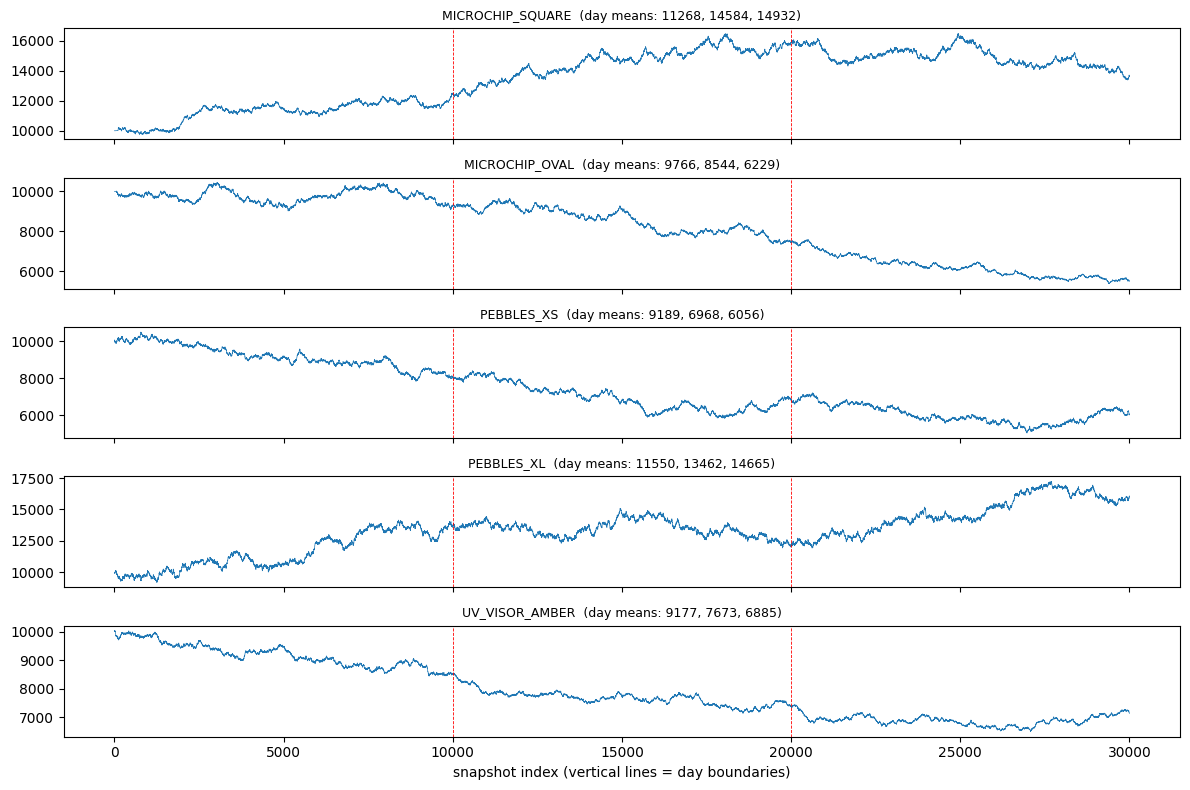

In [28]:
# Plot the 5 biggest drifters
top = day_means.index[:5]
fig, axes = plt.subplots(len(top), 1, figsize=(12, 8), sharex=True)
for ax, p in zip(axes, top):
    s = pv[p].reset_index(drop=True)
    ax.plot(np.arange(len(s)), s.values, lw=0.5)
    for d_idx in [10000, 20000]:
        ax.axvline(d_idx, color='red', lw=0.6, ls='--')
    ax.set_title(f'{p}  (day means: {", ".join(str(int(day_means.loc[p, c])) for c in ["day2","day3","day4"])})',
                 fontsize=9)
axes[-1].set_xlabel('snapshot index (vertical lines = day boundaries)')
plt.tight_layout()

**Read.** Several products drift hundreds-to-thousands of ticks across days
(e.g. `MICROCHIP_SQUARE` 11.3k → 14.9k, `PEBBLES_XS` 9.2k → 6.1k). A naive
"fair = mean of training data" market-making strategy will get steamrolled on
these. **For market-making products, fair has to track the rolling mid**
(EWMA / windowed mean) rather than a fixed level.

Importantly, the PEBBLES *basket constraint* is invariant to this drift —
each leg drifts but the sum stays at 50,000. So the basket arb is robust to
non-stationarity even though the single-leg fairs are not.

## 10 — Trade flow

In [29]:
# Without buyer/seller info, we can only look at trade frequency / size.
trades['size_bucket'] = pd.cut(trades['quantity'], [0, 1, 3, 10, 100],
                                labels=['1', '2-3', '4-10', '11+'])
print(trades.groupby('size_bucket', observed=True)['quantity']
      .agg(['count','sum','mean']).round(2))
print('\nTrades per (day, product):')
print(trades.groupby(['day', 'symbol']).size().describe().round(1))

             count    sum  mean
size_bucket                    
1             8560   8560  1.00
2-3          18010  44505  2.47
4-10          8815  36145  4.10

Trades per (day, product):
count    150.0
mean     235.9
std       21.1
min      174.0
25%      229.0
50%      249.0
75%      255.0
max      255.0
dtype: float64


**Read.** Trade arrivals are extremely uniform — ~229 fills/day for every
product (the canonical bot order flow IMC seeds in). Most trade sizes are
small (1–3 lots). Without buyer/seller tags, we can't lean against any
specific counterparty the way we did in earlier rounds — strategies must
stand on their own.

## 11 — Strategy implications

| Category      | Edge?                | Strategy template |
|---------------|----------------------|-------------------|
| **PEBBLES**   | **basket = 50,000 (std 1.3)** | Snap arb when \|sum−50k\| > threshold. ~hundreds of events/day, reverts in 1 tick. **Highest priority.** |
| **SNACKPACK** | CHOC+VAN pair (std 76); secondary 3-asset (std 63) | z-score pair trade, slower reversion (k=500–1000). Smaller size. |
| Other 8       | none structural       | Per-leg market-making with rolling-mid fair (e.g. EWMA-based) and inventory skew, position cap 10. |

Concrete next steps:

1. **PEBBLES backtest** — write a thresholded basket-arb strategy and verify
   PnL on day 2/3/4 with the Round-5 backtester. Tune entry threshold, leg
   sizing under the position-10 constraint.
2. **SNACKPACK pairs** — backtest a z-score pair on CHOC+VAN with entry/exit
   bands; treat the trio as an optional add-on.
3. **Generic MM trader** — single template parameterised by product fair
   model (EWMA span) and quote sizing. Drop in for the remaining 41 products.
4. **Manual (Ignith)** — wait for the in-round Ashflow Alpha articles, but
   pre-build the optimiser: with `fee = (vol/100)² · 1M`, marginal cost of
   capital is `2v/100² · 1M = 200v` for volume `v` — so size each position
   where expected return per unit capital exceeds the fee.